### El proposito de este workbook es entender si aplicar PCA a los modelos subsiguientes para resolver el problema de iunigo 

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import offsetbox
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import normalize
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
import seaborn as sns
from sklearn.decomposition import PCA
%matplotlib inline

In [10]:
# Lectura del dataset
df = pd.read_csv('../Datos/ip_a_procesar.csv')



In [11]:
# Dummies para poder hacer el proceso de PCA: Sexo, tipo de vehiculo y plataforma del telefono
sexo = pd.get_dummies(df.Sexo,prefix='sexo', prefix_sep='_',drop_first=True)
df = pd.concat([df,sexo],axis=1)

In [12]:
tipo_vehiculo = pd.get_dummies(df.tipo_de_vehiculo,prefix='tipo', prefix_sep='_',drop_first=True)
df = pd.concat([df,tipo_vehiculo],axis=1)

In [13]:
df.platform.fillna('Android')
plataforma = pd.get_dummies(df.platform,prefix='plat_', prefix_sep='_',drop_first=True)
df = pd.concat([df,plataforma],axis=1)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67602 entries, 0 to 67601
Data columns (total 21 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   is_0km                         67602 non-null  int64  
 1   stated_amount                  67602 non-null  float64
 2   plan_id                        67602 non-null  int64  
 3   zip_code                       67602 non-null  int64  
 4   riesgo_bcra                    60632 non-null  float64
 5   cantidad_aseguradoras_previas  42807 non-null  float64
 6   vehicle_score                  42807 non-null  float64
 7   cantidad_siniestros            67602 non-null  float64
 8   tipo                           42807 non-null  float64
 9   participant_code               42807 non-null  float64
 10  Edad                           67602 non-null  int64  
 11  Sexo                           67602 non-null  object 
 12  antiguedad_años                67602 non-null 

In [15]:
df = df.drop(['Sexo','tipo_de_vehiculo','platform'],axis=1)

In [16]:
df =df.fillna(0)  # completamos los faltantes

In [ ]:
# Normalizar antes de usar PCA

In [17]:
std_sclr = StandardScaler()

df_std = pd.DataFrame(std_sclr.fit_transform(df), index=df.index, columns=df.columns)



In [11]:
pca_ip = PCA()
pca_ip.fit(df_std)

PCA()

In [12]:
columnas = ['PC1', 'PC2', 'PC3', 'PC4','PC5', 'PC6', 'PC7', 'PC8', 'PC9', 'PC10', 'PC11', 'PC12','PC13', 'PC14', 'PC15', 'PC16','PC17','PC18']

In [13]:
pca_loadings = pd.DataFrame(pca_ip.components_.T, index=df.columns, columns=columnas)
pca_loadings

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16,PC17,PC18
is_0km,-0.116272,0.231790,0.298692,0.045922,0.100711,0.317561,-0.450810,-0.005364,0.445201,0.196167,0.011207,-0.478860,-0.208790,-0.125910,-0.031497,0.003692,-0.024739,-0.000400
stated_amount,-0.181752,0.522640,-0.052180,0.159384,-0.001257,0.027675,-0.119603,0.220315,-0.131011,-0.028331,-0.095447,0.220110,-0.102195,0.236198,0.650059,0.141022,-0.133620,-0.000315
plan_id,-0.015917,0.290650,0.158410,-0.200095,0.086543,0.204430,0.387929,-0.588808,-0.088237,-0.421088,-0.224962,-0.161174,-0.199662,0.021842,0.034646,-0.019130,-0.007925,0.003807
zip_code,0.023798,-0.127320,-0.187264,0.331836,0.089267,0.741118,0.408777,0.097778,0.081783,0.146837,0.223901,0.140841,-0.073805,0.013433,0.014415,0.007408,0.005459,-0.004352
riesgo_bcra,0.092637,0.284022,0.055350,-0.380960,-0.295431,0.022214,0.171792,-0.232020,-0.146895,0.603376,0.368132,-0.091794,0.213137,0.064789,0.092307,0.049797,0.034997,0.000331
cantidad_aseguradoras_previas,0.428340,0.040150,0.072149,0.089221,0.009670,-0.003079,-0.042545,0.030115,0.016902,0.041210,-0.074545,-0.025752,-0.090668,0.329730,0.040376,-0.313561,0.241188,0.718093
vehicle_score,0.362671,0.152590,0.095960,0.023777,0.039989,0.050724,-0.029541,-0.000307,-0.022852,0.003678,-0.100249,0.237481,0.130536,-0.825881,0.215919,-0.026950,0.076933,0.104877
cantidad_siniestros,0.415829,0.060165,0.108202,0.107468,0.018989,0.002800,-0.045679,0.017108,-0.007700,0.066489,-0.168597,0.039897,-0.116950,0.205287,-0.025868,0.273618,0.621173,-0.495734
tipo,0.410102,0.115383,0.058322,0.034151,0.039160,0.022409,-0.024437,0.027333,0.043749,-0.063760,-0.008695,0.042417,0.073810,0.116335,-0.281167,0.655923,-0.497446,0.164247
participant_code,0.419127,0.046833,0.076239,0.074226,-0.011201,-0.003201,-0.019950,0.003767,-0.027838,0.108448,-0.104893,0.029519,-0.079926,0.128607,-0.004961,-0.564997,-0.507734,-0.431152


- el principal componente tiene como contribuyentes de peso 7 columnas.
- el segundo componente tiene una que destaca, el stated_amount.
- en el tercer componente, la plataforma del telefono y el indicador de usuario creado en la app son los mas reelevantes

In [21]:
def plot_explained_variance(components_count, X):

    model_pca = PCA(components_count).fit(X)

    explained_variance = model_pca.explained_variance_ratio_

   

    cumulative_explained_variance = np.cumsum(explained_variance)

    print(cumulative_explained_variance)

    plt.plot(cumulative_explained_variance)
    plt.xlabel('número de componentes')
    plt.ylabel('% de varianza explicada');
    plt.plot()    

[0.2534814  0.36368668 0.44185964 0.50645885 0.56448056 0.6183475
 0.67111435 0.72312009 0.77128908 0.81674037 0.85895543 0.89926486
 0.93247455 0.95365983 0.96951821 0.98333784 0.99449565 1.        ]


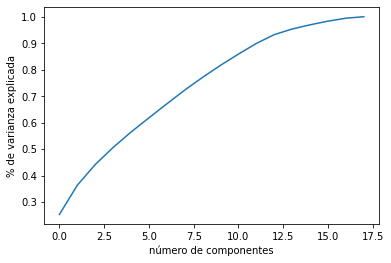

In [22]:
plot_explained_variance(components_count = len(df.columns), X = df_std)


In [23]:
# guardo los datos para usarlos en las pruebas de los modelos.

In [141]:
Y_train.to_csv('../Datos/ytrain.csv',index=False)
Y_test.to_csv('../Datos/ytest.csv',index=False)

In [24]:
### para poder explicar el 90% de la varianza tengo que llegar a 14 componentes sobre 18, no es una gran mejora!!!!